<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Practica20_Ejercicios_de_EDA_usando_airquality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 20: Ejercicios de EDA usando AirQuality

Nombre: Oscar Morales Martinez

Materia: Programación para analítica descriptiva y predictiva

Carrera: Maestría en Inteligencia Artificial y Analítica de Datos

## Instrucciones:

1. Descarga el archivo AirQuality.csv, proporcionado en esta tarea. También lo puedes encontrar en recursos.
2. Crea un notebook en colab y guarda el archivo csv  en tu drive.
3. Agrega secciones en el colab poniendo como título el nombre de cada ejercicio

## Ejercicio 01: Introducción del dataset

Incluye una sección donde expliques:

* Nombre del dataset
* Fuente de donde fue obtenido
* Número de observaciones
* Número de variables
* Descripción de las variables

También debes mostrar:

* Las primeras filas del dataset (head())
* La estructura del dataset (info())

**Nombre del dataset:** AirQuality

**Fuente:**
El conjunto de datos utilizado corresponde a registros de calidad del aire, comúnmente asociados al repositorio de Machine Learning de UCI, aunque la fuente exacta puede variar dependiendo del material entregado en la actividad (Campus Virtual).

Paso 1: Importar librerias y establecer tema para las graficas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Paso 2: Acceso a Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Paso 3: Cargar dataset

In [3]:
path = "/content/drive/MyDrive/ClassFiles/AirQuality.csv"
df = pd.read_csv(path, sep=";", decimal=",")

Paso 4: Mostrar las primeras filas del dataset

In [4]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


Paso 6: Mostrar la estructura del dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


Paso 7: Eliminar columnas vacias

In [6]:
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors="ignore")

Paso 8: Crear columna DateTime basado en Date y Time

In [7]:
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

Paso 9: Obtenemos numero de observaciones

In [8]:
df.shape[0]

9471

Paso 10: Obtenemos numero de variables

In [9]:
df.shape[1]

16

Paso 11: Despues de la limpieza mostramos nuevamente las primeras filas del dataset

In [12]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


Paso 12: Despues de la limpieza mostramos nuevamente la estructura del dataset

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   object        
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   float64       
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
 15  DateTime       9357 n

**Descripcion de las variables.**

El dataset contiene registros relacionados con la calidad del aire en diferentes momentos. Se creo una nueva columna llamada DateTime, la cual combina la fecha y la hora para facilitar futuros analisis temporales. Tambien se observa que el conjunto de datos incluye variables numericas, temporales y mediciones de sensores ambientales.

##Ejercicio 02: Exploración inicial de datos

Realiza lo siguiente:

* Identificar valores faltantes
* Analizar tipos de variables
* Revisar posibles valores atípicos
* Mostrar estadísticas descriptivas básicas (describe())

Explica brevemente lo que observas.

Paso 1: Identificar valores faltantes

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# -200 representa datos faltantes
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)
df.isna().sum()

,0
Date,114
Time,114
CO(GT),1797
PT08.S1(CO),480
NMHC(GT),8557
C6H6(GT),480
PT08.S2(NMHC),480
NOx(GT),1753
PT08.S3(NOx),480
NO2(GT),1756


Paso 2: Analizar tipos de variables

In [17]:
df.dtypes

,0
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


Paso 3: Revisar posibles valores atipicos

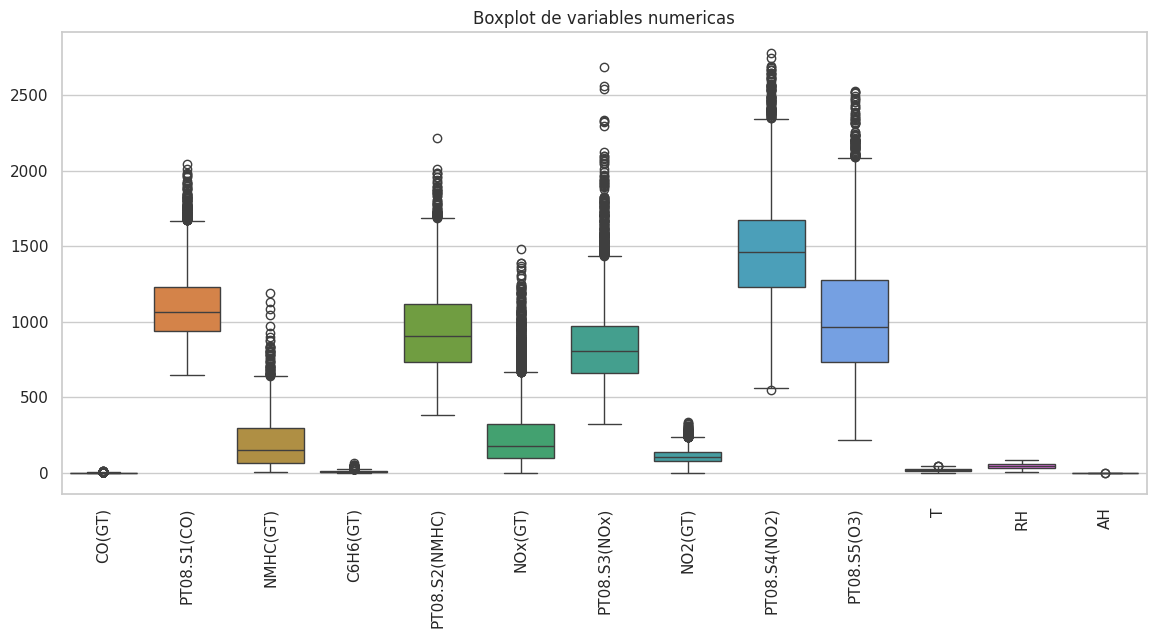

In [19]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Boxplot de variables numericas")
plt.show()

Paso 4: Estadisticas descriptivas basicas

In [20]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN


**Interpretacion:**

En la exploracion inicial se observan valores faltantes en varias columnas, sobre todo en variables relacionadas con contaminantes. Esto indica que el dataset presenta registros incompletos. Las estadisticas descriptivas muestran medidas como promedio, desviacion estandar y rangos, lo cual ayuda a entender mejor el comportamiento de cada variable. Ademas, el boxplot general permite notar la presencia de posibles valores atipicos en algunas columnas.

## Ejercicio 03: Análisis univariado
Analiza una variable individualmente.

Para variables numéricas, elige algunas de las siguientes herramientas:

* Histogramas + KDE
* Boxplot

Para variables categóricas, si existe, elige una de ellas incluye una de las siguientes herramientas (elige la que quieras):

* Gráficas de barras
* Gráficas de pastel

En cada gráfico debes interpretar brevemente los resultados.

Paso 1: Histograma de temperatura

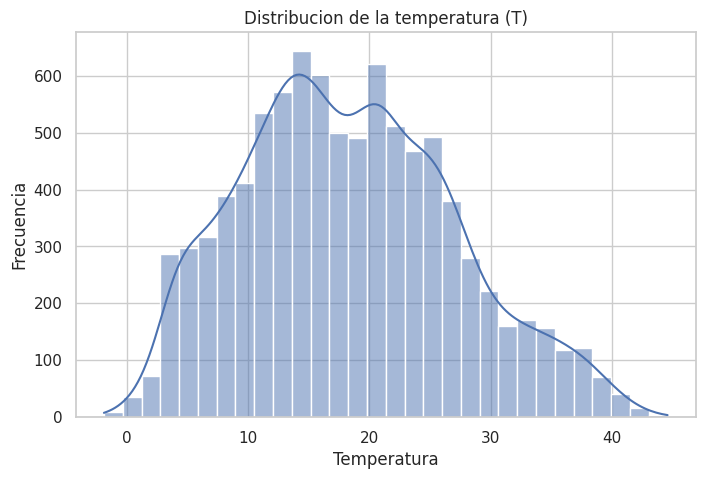

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df["T"].dropna(), bins=30, kde=True)
plt.title("Distribucion de la temperatura (T)")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")
plt.show()

**Interpretacion:**

Este histograma permite visualizar como se distribuyen los valores de la temperatura. Se puede identificar en que rangos se concentran mas las observaciones y si la distribucion presenta simetria o algún sesgo. Esto ayuda a conocer el comportamiento general de esta variable.

Paso 2: Boxplot de CO(GT)

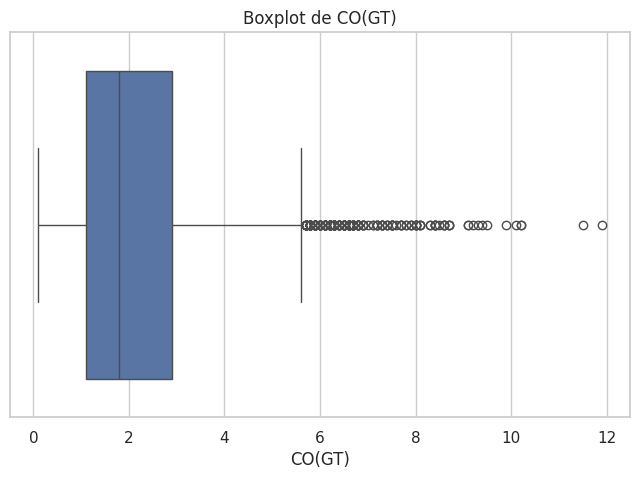

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["CO(GT)"])
plt.title("Boxplot de CO(GT)")
plt.xlabel("CO(GT)")
plt.show()

**Interpretacion:**

El diagrama de caja muestra la mediana, la dispersión y la existencia de valores extremos. Si se observan puntos fuera de los límites principales, eso indica la presencia de posibles outliers. Este tipo de comportamiento es comun en datos ambientales.

Paso 3: Creamos la columna Month ya que el dataset no cuenta con variables categoricas

In [23]:
df["Month"] = df["DateTime"].dt.month

Paso 4: Grafica de barras para la variable Month

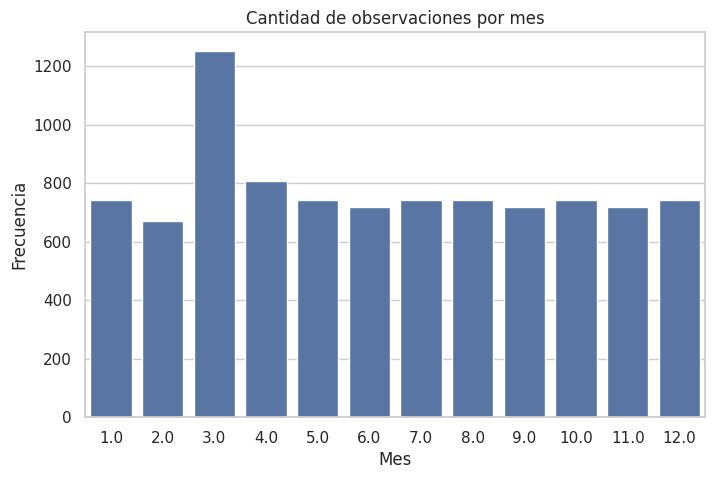

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Month")
plt.title("Cantidad de observaciones por mes")
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.show()

**Interpretacion:**

La grafica de barras muestra como se distribuyen las observaciones a lo largo de los meses. Esto permite verificar si existen periodos con mayor cantidad de registros y si el dataset se encuentra balanceado en el tiempo.

## Ejercicio 04: Análisis bivariado

Analiza relaciones entre dos variables. Elige las variables que gustes

**Numérica vs Numérica**

Utiliza:

* scatter plots

Explica qué relaciones observas.

Paso 1: Relacion entre temperatura (T) y humedad relativa (RH) (Grafica de dispersion)

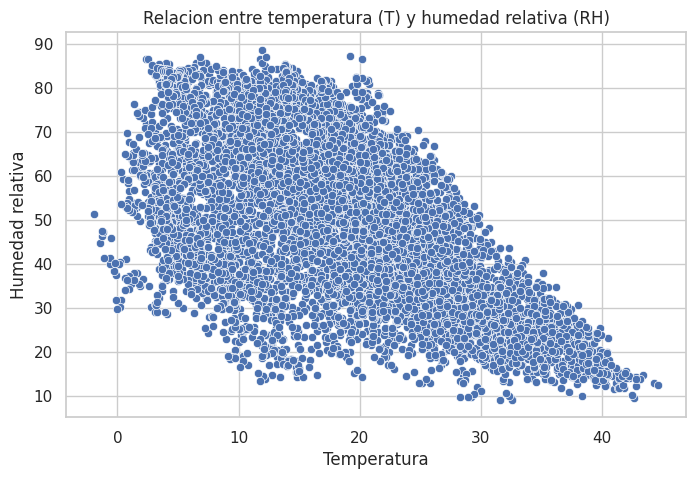

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="T", y="RH")
plt.title("Relacion entre temperatura (T) y humedad relativa (RH)")
plt.xlabel("Temperatura")
plt.ylabel("Humedad relativa")
plt.show()

**Interpretacion:**

El grafico de dispersion permite analizar si hay una tendencia entre la temperatura y la humedad relativa. Si los puntos muestran una direccion general, se puede pensar que existe una relacion entre ambas variables. Si los puntos estan muy dispersos, la relacion seria debil.

Paso 2: Relacion entre C6H6(GT) y PT08.S2(NMHC)

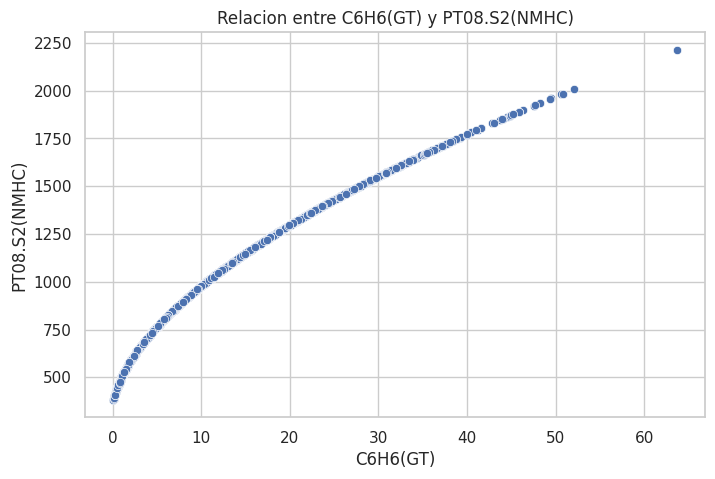

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="C6H6(GT)", y="PT08.S2(NMHC)")
plt.title("Relacion entre C6H6(GT) y PT08.S2(NMHC)")
plt.xlabel("C6H6(GT)")
plt.ylabel("PT08.S2(NMHC)")
plt.show()

**Interpretacion:**

Este grafico permite revisar si existe una asociacion entre la variable C6H6(GT) y la respuesta del sensor PT08.S2(NMHC). Una tendencia clara en los puntos podria indicar que el sensor reacciona de manera consistente frente a cambios en la concentracion del contaminante.

## Ejercicio 05: Análisis multivariado
Realiza análisis considerando múltiples variables.

Incluye: Mapa de Calor - Correlación entre variables

Paso 1: Mapa de calor de correlacion entre variables numericas

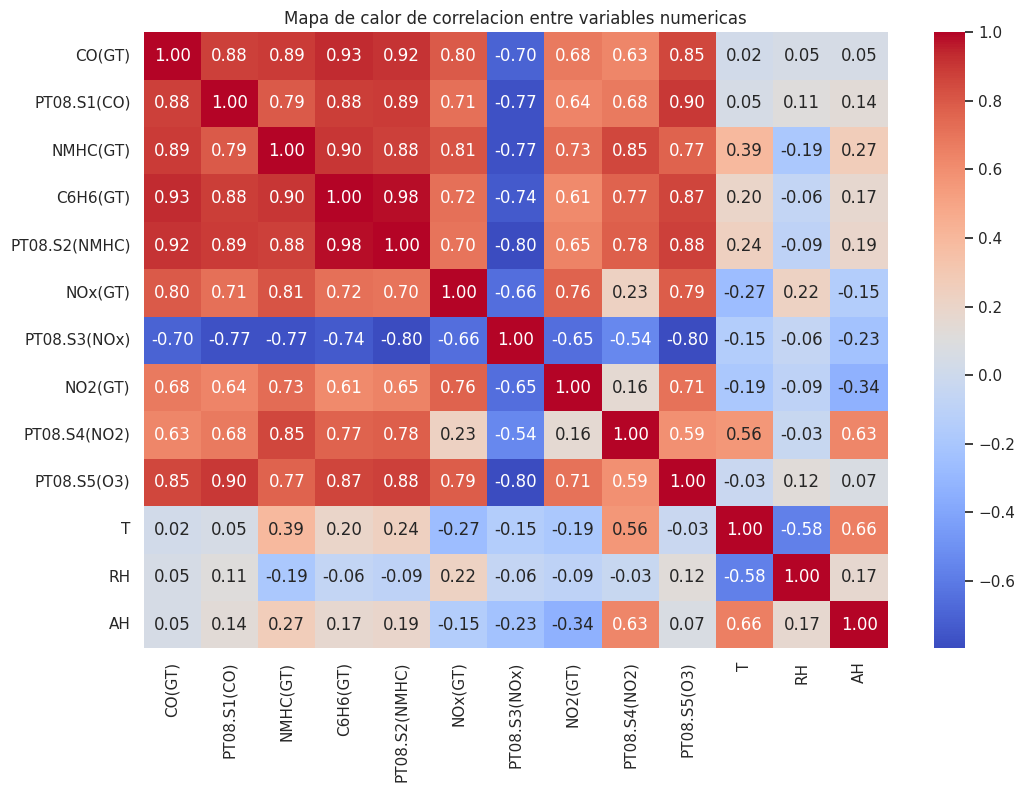

In [27]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de calor de correlacion entre variables numericas")
plt.show()

**Interpretacion:**

El mapa de calor permite identificar relaciones lineales entre las variables numericas. Los valores mas cercanos a 1 representan correlaciones positivas fuertes, mientras que los cercanos a -1 indican correlaciones negativas fuertes. Esto ayuda a detectar variables que presentan comportamientos similares y a reconocer patrones de asociacion dentro del dataset.

## Ejercicio 06: Identificación de patrones

Con base en el análisis realizado, responde:

**¿Qué patrones importantes encontraste?**

Durante el analisis se detecto la presencia de valores faltantes en distintas variables, especialmente en aquellas relacionadas con contaminantes. Tambien se observaron valores atipicos en varias variables numericas.

**¿Existen relaciones entre variables?**

Si se identifican relaciones entre algunas variables, principalmente entre sensores y contaminantes, lo cual sugiere que ciertas mediciones están asociadas entre si.

**¿Se observan clusters naturales?**

En algunos graficos de dispersión pueden notarse ciertas agrupaciones de observaciones, aunque no son completamente definidas. Esto puede indicar comportamientos similares bajo ciertas condiciones ambientales.

**¿Existen outliers?**

Si, los diagramas de caja muestran la presencia de valores atipicos en distintas variables, algo frecuente en datos obtenidos mediante sensores ambientales.

**¿Qué variables parecen ser más relevantes?**

Las variables asociadas con contaminantes y sensores parecen ser las mas relevantes, ya que muestran relaciones interesantes y variabilidad suficiente para aportar informacion util en el analisis.